1. What is K-Nearest Neighbors (KNN) and how does it work?

KNN is a supervised learning algorithm used for classification and regression. It predicts the output by finding the K nearest data points to the new sample and using their labels/values.

Steps:

Choose K.
Calculate distance from the new point to all training points.
Select the K nearest neighbors.
Predict:
Classification: Majority vote.
Regression: Average of neighbors' values.

2. What is the difference between KNN Classification and KNN Regression?
KNN Classification	KNN Regression
Predicts a class label	Predicts a continuous value
Uses majority voting	Uses average (or weighted average)
Example: Spam/Not Spam	Example: House Price Prediction

3. What is the role of the distance metric in KNN?

The distance metric determines which data points are considered nearest neighbors.

Common metrics:

Euclidean Distance
Manhattan Distance
Minkowski Distance

The choice of metric directly affects prediction accuracy.

4. What is the Curse of Dimensionality in KNN?

As the number of features increases:

Distances between points become less meaningful.
Neighbors become less distinguishable.
Accuracy decreases.
Computation becomes slower.

5. How can we choose the best value of K in KNN?
Use cross-validation.
Try different K values.
Choose the K with the highest validation accuracy (or lowest error).
Avoid:
Very small K → Overfitting.
Very large K → Underfitting.

6. What are KD Tree and Ball Tree in KNN?

They are data structures used to speed up nearest-neighbor searches.

KD Tree: Splits data using axis-aligned hyperplanes.
Ball Tree: Splits data into nested hyperspheres.

7. When should you use KD Tree vs. Ball Tree?
KD Tree: Works best for low-dimensional data.
Ball Tree: Better for high-dimensional or irregularly distributed data.

8. What are the disadvantages of KNN?
Slow prediction on large datasets.
Sensitive to feature scaling.
Sensitive to irrelevant features.
Suffers from the curse of dimensionality.
Requires storing the entire training dataset.

9. How does feature scaling affect KNN?

KNN is distance-based, so features with larger values dominate the distance.

Therefore, apply scaling techniques like:

Standardization
Normalization

before using KNN.

10. What is PCA (Principal Component Analysis)?

PCA is an unsupervised dimensionality reduction technique that transforms correlated features into a smaller set of uncorrelated principal components while preserving maximum variance.

11. How does PCA work?
Standardize the data.
Compute the covariance matrix.
Find eigenvalues and eigenvectors.
Sort components by decreasing eigenvalues.
Select top components.
Transform the data onto these components.

12. What is the geometric intuition behind PCA?

PCA finds the directions (axes) where the data varies the most and projects the data onto these directions, reducing dimensions while retaining most information.

13. What is the difference between Feature Selection and Feature Extraction?
Feature Selection	                       Feature Extraction
Selects existing features	               Creates new features
Original features remain	               New transformed features
Example: Select top 10 features         	Example: PCA

14. What are Eigenvalues and Eigenvectors in PCA?
Eigenvectors: Directions of maximum variance (principal components).
Eigenvalues: Amount of variance explained by each eigenvector.

Higher eigenvalue ⇒ More important component.

15. How do you decide the number of components to keep in PCA?

Use the explained variance ratio.

Keep enough components to explain about 90–95% of the total variance.

16. Can PCA be used for classification?

No, PCA itself is not a classifier.

It is used as a preprocessing step to reduce dimensions before applying classifiers like KNN, SVM, or Logistic Regression.

17. What are the limitations of PCA?
Assumes linear relationships.
Difficult to interpret transformed features.
Sensitive to feature scaling.
May lose important information if too many components are removed.

18. How do KNN and PCA complement each other?

PCA reduces the number of features before KNN.

Benefits:

Faster computation.
Reduces noise.
Mitigates the curse of dimensionality.
Can improve KNN accuracy.

19. How does KNN handle missing values in a dataset?

KNN cannot handle missing values directly.

Missing values should be handled first using:

Mean imputation
Median imputation
Mode imputation
KNN imputation

20. What are the key differences between PCA and Linear Discriminant Analysis (LDA)?
PCA	LDA
Unsupervised	Supervised
Maximizes variance	Maximizes class separation
Ignores class labels	Uses class labels
Used for dimensionality reduction	Used for dimensionality reduction and classification
Components ≤ Number of features	Components ≤ Number of classes − 1

In [1]:
# 21. Train a KNN Classifier on the Iris dataset and print model accuracy
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = KNeighborsClassifier(n_neighbors=3)

# Train model
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [2]:
# 22. Train a KNN Regressor on a synthetic dataset and evaluate using Mean Squared Error (MSE)
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Generate dataset
X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=10,
    random_state=42
)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = KNeighborsRegressor(n_neighbors=5)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# MSE
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 108.14198878074414


In [3]:
# 23. Train a KNN Classifier using different distance metrics (Euclidean and Manhattan) and compare accuracy
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Euclidean Distance
euclidean = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
euclidean.fit(X_train, y_train)
pred1 = euclidean.predict(X_test)

# Manhattan Distance
manhattan = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
manhattan.fit(X_train, y_train)
pred2 = manhattan.predict(X_test)

print("Euclidean Accuracy:",
      accuracy_score(y_test, pred1))

print("Manhattan Accuracy:",
      accuracy_score(y_test, pred2))

Euclidean Accuracy: 1.0
Manhattan Accuracy: 1.0


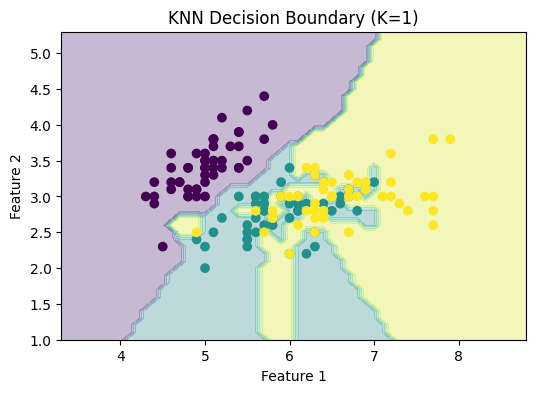

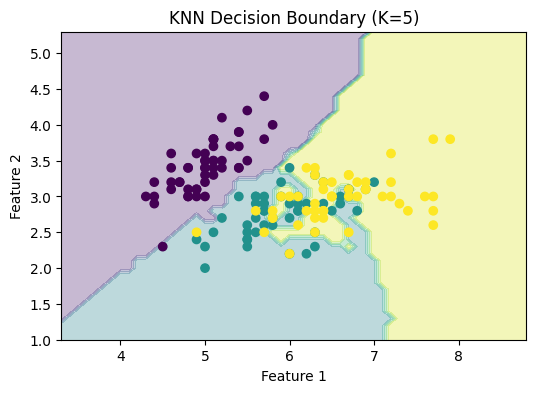

In [4]:
# 24. Train a KNN Classifier with different values of K and visualize decision boundaries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier

# Load only first two features
iris = load_iris()
X = iris.data[:, :2]
y = iris.target

k_values = [1, 5]

for k in k_values:

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X, y)

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.1),
        np.arange(y_min, y_max, 0.1)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,4))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y)
    plt.title(f"KNN Decision Boundary (K={k})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

In [5]:
# 25. Apply Feature Scaling before training a KNN model and compare results with unscaled data
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Without Scaling
model1 = KNeighborsClassifier(n_neighbors=3)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

print("Accuracy without Scaling:",
      accuracy_score(y_test, pred1))

# Apply Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# With Scaling
model2 = KNeighborsClassifier(n_neighbors=3)
model2.fit(X_train_scaled, y_train)

pred2 = model2.predict(X_test_scaled)

print("Accuracy with Scaling:",
      accuracy_score(y_test, pred2))

Accuracy without Scaling: 1.0
Accuracy with Scaling: 1.0
